# Decision Tree Regression - Combined Trial 1 & 2 Data
Predicting `fw_change_g` (4-day change in fresh weight) using the same features and target as the combined-trial neural network model.

# Set Up

In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
TRIAL_1_DATA_PATH = "../Data/CleanData/Trial_1_Mean_Sensor_FW_No_Lag.csv"
TRIAL_2_DATA_PATH = "../Data/CleanData/Trial_2_Mean_Sensor_FW_No_Lag.csv"

def load_trial_1_data(path = TRIAL_1_DATA_PATH):
    df = pd.read_csv(path)
    # add change in fresh weigh variable
    df['fw_change_g'] = df.groupby('plant-id')['total_fresh_weight_g'].diff().fillna(0)
    # drop vairables not in trial 2 and plant-id
    df.drop(columns=['baseline_g', 'volume_flow_rate', 'volume', 'total_fresh_weight_g', 'plant-id'], inplace=True)
    return df

def load_trial_2_data(path = TRIAL_2_DATA_PATH):
    df = pd.read_csv(path)
    df.drop(columns=['plant_id', 'total_fresh_weight_g'], inplace=True)
    return df

def load_combined_data():
    df_1 = load_trial_1_data()
    df_2 = load_trial_2_data()
    combined_df = pd.concat([df_1, df_2], ignore_index=True)
    combined_df.sort_values(by=['day', 'fw_change_g'], inplace=True)
    combined_df = combined_df [ (combined_df['day'] > 0) ].reset_index(drop=True)
    return combined_df

In [6]:
df = load_combined_data()
df

,day,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
0,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,4.0
1,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.2
2,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.7
3,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,7.3
4,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,8.3
...,...,...,...,...,...,...,...,...
135,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,77.0
136,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,78.0
137,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,79.0
138,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,80.0


# Decision Tree Model

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

df = load_combined_data()

target_col = 'fw_change_g'

X = df.drop(columns=[target_col])
y = df[target_col]

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Features: {feature_names}")

Train shape: (112, 7), Test shape: (28, 7)
Features: ['day', 'carbon_dioxide', 'temp_env', 'humidity', 'pressure', 'electrical_conductivity', 'temp_nutr']


## Hyperparameter Tuning (5-Fold Cross-Validation)

In [12]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

base_tree = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV MSE: {-grid_search.best_score_:.4f}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

best_tree = grid_search.best_estimator_

Best params: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV MSE: 29.0771
Best CV RMSE: 5.3923


## Test Set Evaluation

In [13]:
y_pred = best_tree.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'MSE', 'RMSE', 'MAPE'],
    'Value': [r2, mae, mse, rmse, mape]
})

print(f"R-squared:                     {r2:.4f}")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"Root Mean Squared Error (RMSE):{rmse:.4f}")
print(f"Mean Abs. Percentage Error:    {mape:.4f}")

metrics_df

R-squared:                     0.9612
Mean Absolute Error (MAE):     3.7811
Mean Squared Error (MSE):      26.0628
Root Mean Squared Error (RMSE):5.1052
Mean Abs. Percentage Error:    0.2546


,Metric,Value
0,R2,0.961153
1,MAE,3.781080
2,MSE,26.062777
3,RMSE,5.105172
4,MAPE,0.254596


## Cross-Validated Scores (Best Model)

In [14]:
from sklearn.model_selection import cross_val_score

cv_r2_scores = cross_val_score(best_tree, X_train, y_train, cv=kf, scoring='r2')
cv_mae_scores = -cross_val_score(best_tree, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
cv_mse_scores = -cross_val_score(best_tree, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(cv_mse_scores)

for fold in range(len(cv_r2_scores)):
    print(
        f"Fold [{fold+1}/{len(cv_r2_scores)}] "
        f"R2: {cv_r2_scores[fold]:.4f}, "
        f"MAE: {cv_mae_scores[fold]:.4f}, "
        f"MSE: {cv_mse_scores[fold]:.4f}, "
        f"RMSE: {cv_rmse_scores[fold]:.4f}"
    )

print(f"\nMean CV R2:   {np.mean(cv_r2_scores):.4f} (std={np.std(cv_r2_scores):.4f})")
print(f"Mean CV MAE:  {np.mean(cv_mae_scores):.4f} (std={np.std(cv_mae_scores):.4f})")
print(f"Mean CV MSE:  {np.mean(cv_mse_scores):.4f} (std={np.std(cv_mse_scores):.4f})")
print(f"Mean CV RMSE: {np.mean(cv_rmse_scores):.4f} (std={np.std(cv_rmse_scores):.4f})")

Fold [1/5] R2: 0.9137, MAE: 3.7666, MSE: 28.7939, RMSE: 5.3660
Fold [2/5] R2: 0.9610, MAE: 3.5898, MSE: 30.3714, RMSE: 5.5110
Fold [3/5] R2: 0.8735, MAE: 4.7472, MSE: 53.3865, RMSE: 7.3066
Fold [4/5] R2: 0.9805, MAE: 2.5317, MSE: 10.4039, RMSE: 3.2255
Fold [5/5] R2: 0.9584, MAE: 3.6922, MSE: 22.4300, RMSE: 4.7360

Mean CV R2:   0.9374 (std=0.0387)
Mean CV MAE:  3.6655 (std=0.7032)
Mean CV MSE:  29.0771 (std=14.0398)
Mean CV RMSE: 5.2290 (std=1.3169)


## Feature Importance

day                        0.928604
carbon_dioxide             0.049123
humidity                   0.011594
temp_env                   0.005976
electrical_conductivity    0.004541
temp_nutr                  0.000162
pressure                   0.000000
dtype: float64


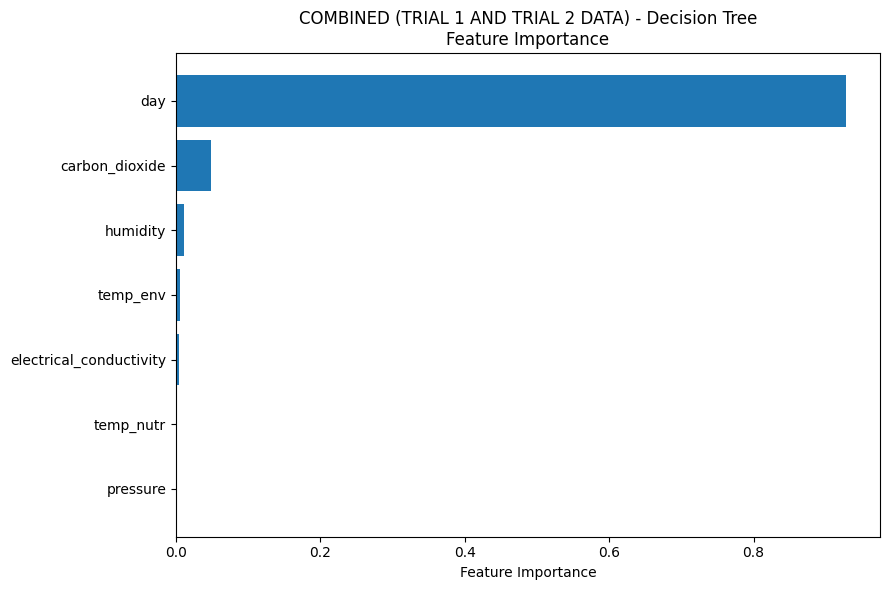

In [10]:
import matplotlib.pyplot as plt
import os

os.makedirs('../Figures', exist_ok=True)

importances = pd.Series(best_tree.feature_importances_, index=feature_names).sort_values(ascending=False)

print(importances)

plt.figure(figsize=(9, 6))
plt.barh(importances.index[::-1], importances.values[::-1])
plt.xlabel("Feature Importance")
plt.title("COMBINED (TRIAL 1 AND TRIAL 2 DATA) - Decision Tree\nFeature Importance")
plt.tight_layout()
plt.savefig('../Figures/combined_decisiontree_feature_importance.png', bbox_inches='tight')
plt.show()

## Reproduce Reference Graphs (Leave-One-Out Cross-Validation)

In [20]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

loo = LeaveOneOut()
oof_preds = cross_val_predict(best_tree, X, y, cv=loo)

r2_loo = r2_score(y, oof_preds)
rmse_loo = np.sqrt(mean_squared_error(y, oof_preds))
n_loo = len(y)

print(f"Leave-One-Out R-squared: {r2_loo:.4f}")
print(f"Leave-One-Out RMSE: {rmse_loo:.4f}")
print(f"n = {n_loo}")

Leave-One-Out R-squared: 0.9476
Leave-One-Out RMSE: 5.4364
n = 140


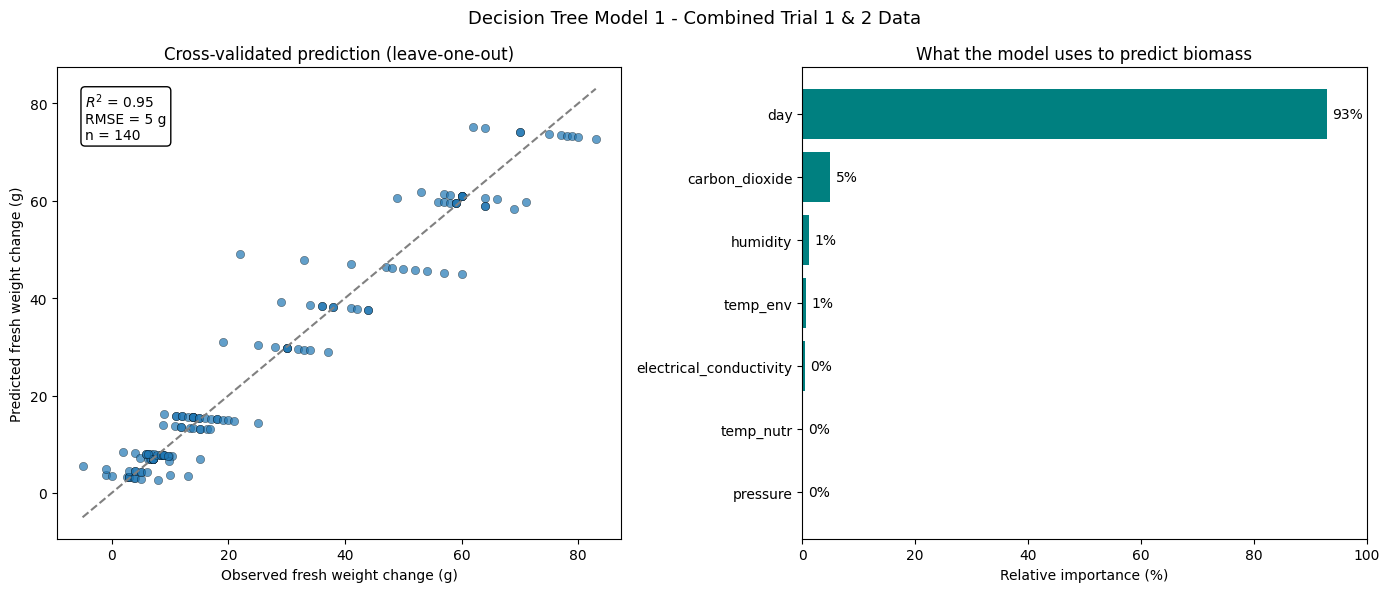

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Left panel: cross-validated (leave-one-out) predicted vs observed ----
ax = axes[0]
ax.scatter(y, oof_preds, alpha=0.7, edgecolor='black', linewidth=0.3)

min_val = min(y.min(), oof_preds.min())
max_val = max(y.max(), oof_preds.max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray')

textstr = f"$R^2$ = {r2_loo:.2f}\nRMSE = {rmse_loo:.0f} g\nn = {n_loo}"
ax.text(
    0.05, 0.95, textstr, transform=ax.transAxes,
    va='top', ha='left',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black')
)

ax.set_xlabel("Observed fresh weight change (g)")
ax.set_ylabel("Predicted fresh weight change (g)")
ax.set_title("Cross-validated prediction (leave-one-out)")

# ---- Right panel: relative feature importance ----
ax2 = axes[1]
relative_importance_pct = (importances * 100)
plot_importance = relative_importance_pct.iloc[::-1]  # smallest to largest for horizontal bar plot
bars = ax2.barh(plot_importance.index, plot_importance.values, color='teal')

for bar, value in zip(bars, plot_importance.values):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%", va='center')

ax2.set_xlim(0, 100)
ax2.set_xlabel("Relative importance (%)")
ax2.set_title("What the model uses to predict biomass")

plt.suptitle("Decision Tree Model 1 - Combined Trial 1 & 2 Data", fontsize=13)
plt.tight_layout()
plt.savefig('../Figures/combined_decisiontree_model1_loocv_prediction_and_feature_importance.png', bbox_inches='tight')
plt.show()

# Decision Tree Model 2
Dropping Day Feature

In [15]:
df2 = load_combined_data()
df2 = df2.drop(columns=['day'])  # drop day feature for model 2

target_col = 'fw_change_g'

X2 = df2.drop(columns=[target_col])
y2 = df2[target_col]

feature_names_2 = X2.columns.tolist()

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f"Train shape: {X2_train.shape}, Test shape: {X2_test.shape}")
print(f"Features: {feature_names_2}")

Train shape: (112, 6), Test shape: (28, 6)
Features: ['carbon_dioxide', 'temp_env', 'humidity', 'pressure', 'electrical_conductivity', 'temp_nutr']


## Hyperparameter Tuning (5-Fold Cross-Validation)

In [16]:
param_grid_2 = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

kf2 = KFold(n_splits=5, shuffle=True, random_state=42)

base_tree_2 = DecisionTreeRegressor(random_state=42)

grid_search_2 = GridSearchCV(
    estimator=base_tree_2,
    param_grid=param_grid_2,
    cv=kf2,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)

grid_search_2.fit(X2_train, y2_train)

print(f"Best params: {grid_search_2.best_params_}")
print(f"Best CV MSE: {-grid_search_2.best_score_:.4f}")
print(f"Best CV RMSE: {np.sqrt(-grid_search_2.best_score_):.4f}")

best_tree_2 = grid_search_2.best_estimator_

Best params: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV MSE: 28.9629
Best CV RMSE: 5.3817


## Test Set Evaluation

In [17]:
y2_pred = best_tree_2.predict(X2_test)

r2_2 = r2_score(y2_test, y2_pred)
mae_2 = mean_absolute_error(y2_test, y2_pred)
mse_2 = mean_squared_error(y2_test, y2_pred)
rmse_2 = np.sqrt(mse_2)
mape_2 = mean_absolute_percentage_error(y2_test, y2_pred)

metrics_df_2 = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'MSE', 'RMSE', 'MAPE'],
    'Value': [r2_2, mae_2, mse_2, rmse_2, mape_2]
})

print(f"R-squared:                     {r2_2:.4f}")
print(f"Mean Absolute Error (MAE):     {mae_2:.4f}")
print(f"Mean Squared Error (MSE):      {mse_2:.4f}")
print(f"Root Mean Squared Error (RMSE):{rmse_2:.4f}")
print(f"Mean Abs. Percentage Error:    {mape_2:.4f}")

metrics_df_2

R-squared:                     0.9615
Mean Absolute Error (MAE):     3.7724
Mean Squared Error (MSE):      25.8506
Root Mean Squared Error (RMSE):5.0843
Mean Abs. Percentage Error:    0.2383


,Metric,Value
0,R2,0.961469
1,MAE,3.772401
2,MSE,25.850587
3,RMSE,5.084347
4,MAPE,0.238265


## Cross-Validated Scores (Best Model)

In [18]:
cv_r2_scores_2 = cross_val_score(best_tree_2, X2_train, y2_train, cv=kf2, scoring='r2')
cv_mae_scores_2 = -cross_val_score(best_tree_2, X2_train, y2_train, cv=kf2, scoring='neg_mean_absolute_error')
cv_mse_scores_2 = -cross_val_score(best_tree_2, X2_train, y2_train, cv=kf2, scoring='neg_mean_squared_error')
cv_rmse_scores_2 = np.sqrt(cv_mse_scores_2)

for fold in range(len(cv_r2_scores_2)):
    print(
        f"Fold [{fold+1}/{len(cv_r2_scores_2)}] "
        f"R2: {cv_r2_scores_2[fold]:.4f}, "
        f"MAE: {cv_mae_scores_2[fold]:.4f}, "
        f"MSE: {cv_mse_scores_2[fold]:.4f}, "
        f"RMSE: {cv_rmse_scores_2[fold]:.4f}"
    )

print(f"\nMean CV R2:   {np.mean(cv_r2_scores_2):.4f} (std={np.std(cv_r2_scores_2):.4f})")
print(f"Mean CV MAE:  {np.mean(cv_mae_scores_2):.4f} (std={np.std(cv_mae_scores_2):.4f})")
print(f"Mean CV MSE:  {np.mean(cv_mse_scores_2):.4f} (std={np.std(cv_mse_scores_2):.4f})")
print(f"Mean CV RMSE: {np.mean(cv_rmse_scores_2):.4f} (std={np.std(cv_rmse_scores_2):.4f})")

Fold [1/5] R2: 0.9136, MAE: 3.7687, MSE: 28.8124, RMSE: 5.3677
Fold [2/5] R2: 0.9608, MAE: 3.7354, MSE: 30.4772, RMSE: 5.5206
Fold [3/5] R2: 0.8728, MAE: 4.7823, MSE: 53.6692, RMSE: 7.3259
Fold [4/5] R2: 0.9821, MAE: 2.4412, MSE: 9.5710, RMSE: 3.0937
Fold [5/5] R2: 0.9587, MAE: 3.7390, MSE: 22.2846, RMSE: 4.7207

Mean CV R2:   0.9376 (std=0.0393)
Mean CV MAE:  3.6933 (std=0.7434)
Mean CV MSE:  28.9629 (std=14.3761)
Mean CV RMSE: 5.2057 (std=1.3650)


## Feature Importance

humidity                   0.437490
electrical_conductivity    0.373956
temp_env                   0.166333
temp_nutr                  0.019303
pressure                   0.002918
carbon_dioxide             0.000000
dtype: float64


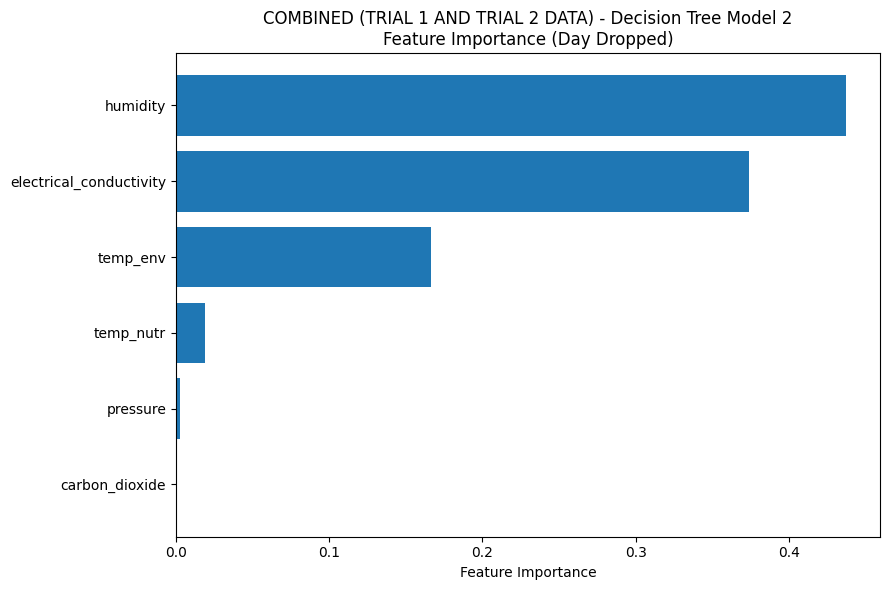

In [19]:
importances_2 = pd.Series(best_tree_2.feature_importances_, index=feature_names_2).sort_values(ascending=False)

print(importances_2)

plt.figure(figsize=(9, 6))
plt.barh(importances_2.index[::-1], importances_2.values[::-1])
plt.xlabel("Feature Importance")
plt.title("COMBINED (TRIAL 1 AND TRIAL 2 DATA) - Decision Tree Model 2\nFeature Importance (Day Dropped)")
plt.tight_layout()
plt.savefig('../Figures/combined_decisiontree_model2_feature_importance.png', bbox_inches='tight')
plt.show()